In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("niccosimonetti/nasa-exoplanet-archive")

print("Path to dataset files:", path)

100%|██████████| 6.64M/6.64M [00:00<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/niccosimonetti/nasa-exoplanet-archive/versions/2


In [4]:
import pandas as pd
import numpy as np

In [9]:
df=pd.read_csv("/root/.cache/kagglehub/datasets/niccosimonetti/nasa-exoplanet-archive/versions/2/PS_2025.08.14_09.21.47_dataset.csv")


In [10]:
data.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
2,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
3,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2011-08,2014-07-23
4,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
unique_planets = df.drop_duplicates(subset='pl_name')

In [12]:
year_counts = (
    unique_planets['disc_year']
    .value_counts()
    .sort_index()
)


In [14]:
sns.set_style("whitegrid")

plt.figure(figsize=(16,7), dpi=120)


<Figure size 1920x840 with 0 Axes>

<Figure size 1920x840 with 0 Axes>

In [37]:
# -----------------------------
# DATA CLEANING
# -----------------------------

# Remove duplicate planets
df = df.drop_duplicates(subset='pl_name')

# Keep useful columns
columns = [
    'pl_name',
    'hostname',
    'disc_year',
    'discoverymethod',
    'pl_orbper',
    'pl_rade',
    'pl_bmassj',
    'pl_eqt',
    'pl_orbeccen',
    'pl_orbsmax',
    'st_teff',
    'st_mass',
    'st_met',
    'sy_dist',
    'ra',
    'dec'
]

df = df[columns]

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (5972, 16)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5972 entries, 0 to 38720
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          5972 non-null   object 
 1   hostname         5972 non-null   object 
 2   disc_year        5972 non-null   int64  
 3   discoverymethod  5972 non-null   object 
 4   pl_orbper        5415 non-null   float64
 5   pl_rade          3552 non-null   float64
 6   pl_bmassj        2074 non-null   float64
 7   pl_eqt           2453 non-null   float64
 8   pl_orbeccen      3020 non-null   float64
 9   pl_orbsmax       3630 non-null   float64
 10  st_teff          5156 non-null   float64
 11  st_mass          4956 non-null   float64
 12  st_met           3635 non-null   float64
 13  sy_dist          5837 non-null   float64
 14  ra               5972 non-null   float64
 15  dec              5972 non-null   float64
dtypes: float64(12), int64(1), object(3)
memory usage: 793.2+ KB


In [39]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
pl_bmassj,3898
pl_eqt,3519
pl_orbeccen,2952
pl_rade,2420
pl_orbsmax,2342
st_met,2337
st_mass,1016
st_teff,816
pl_orbper,557
sy_dist,135


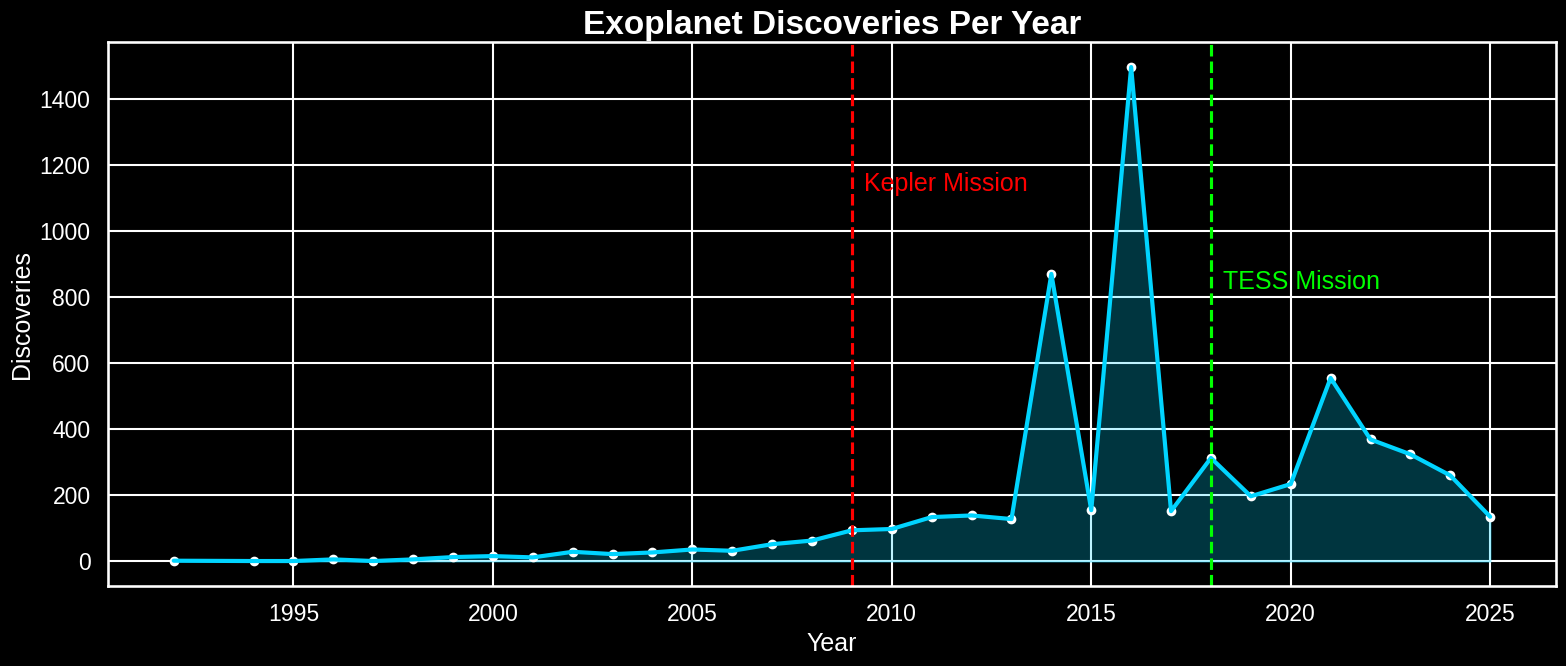

In [40]:
discoveries = (
    df['disc_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(16,7))

plt.plot(
    discoveries.index,
    discoveries.values,
    color='#00d4ff',
    linewidth=3
)

plt.fill_between(
    discoveries.index,
    discoveries.values,
    color='#00d4ff',
    alpha=0.25
)

plt.scatter(
    discoveries.index,
    discoveries.values,
    color='white',
    s=30
)

plt.title(
    'Exoplanet Discoveries Per Year',
    fontsize=24,
    weight='bold'
)

plt.xlabel('Year')
plt.ylabel('Discoveries')

# Kepler Mission
plt.axvline(2009, color='red', linestyle='--')
plt.text(
    2009.3,
    max(discoveries.values)*0.75,
    'Kepler Mission',
    color='red'
)

# TESS Mission
plt.axvline(2018, color='lime', linestyle='--')
plt.text(
    2018.3,
    max(discoveries.values)*0.55,
    'TESS Mission',
    color='lime'
)

plt.tight_layout()
plt.show()

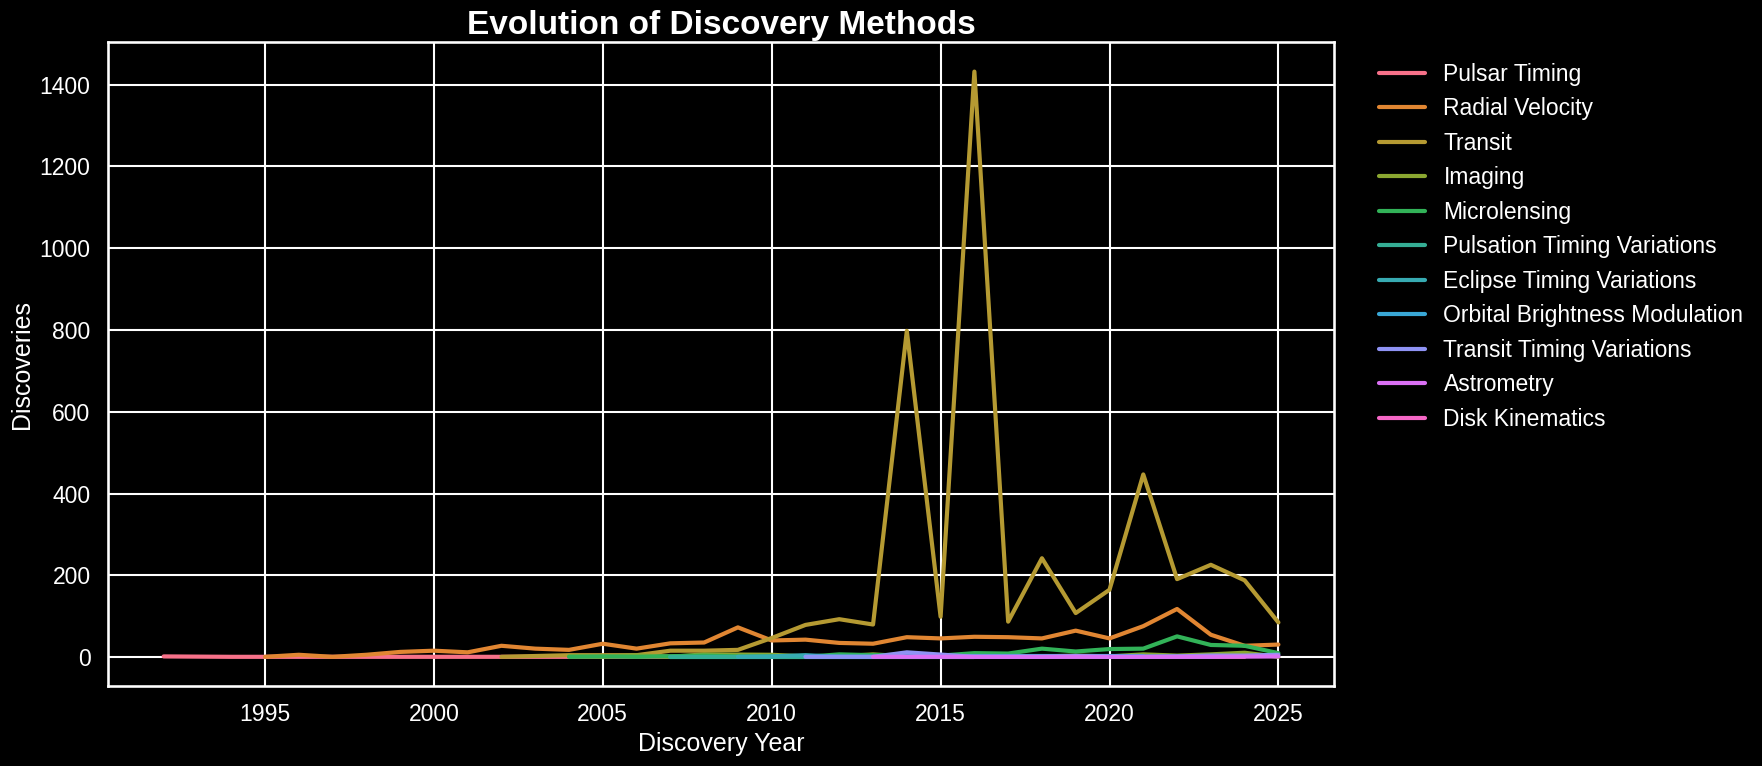

In [41]:
method_year = (
    df.groupby(['disc_year', 'discoverymethod'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(18,8))

sns.lineplot(
    data=method_year,
    x='disc_year',
    y='count',
    hue='discoverymethod',
    linewidth=3
)

plt.title(
    'Evolution of Discovery Methods',
    fontsize=24,
    weight='bold'
)

plt.xlabel('Discovery Year')
plt.ylabel('Discoveries')

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

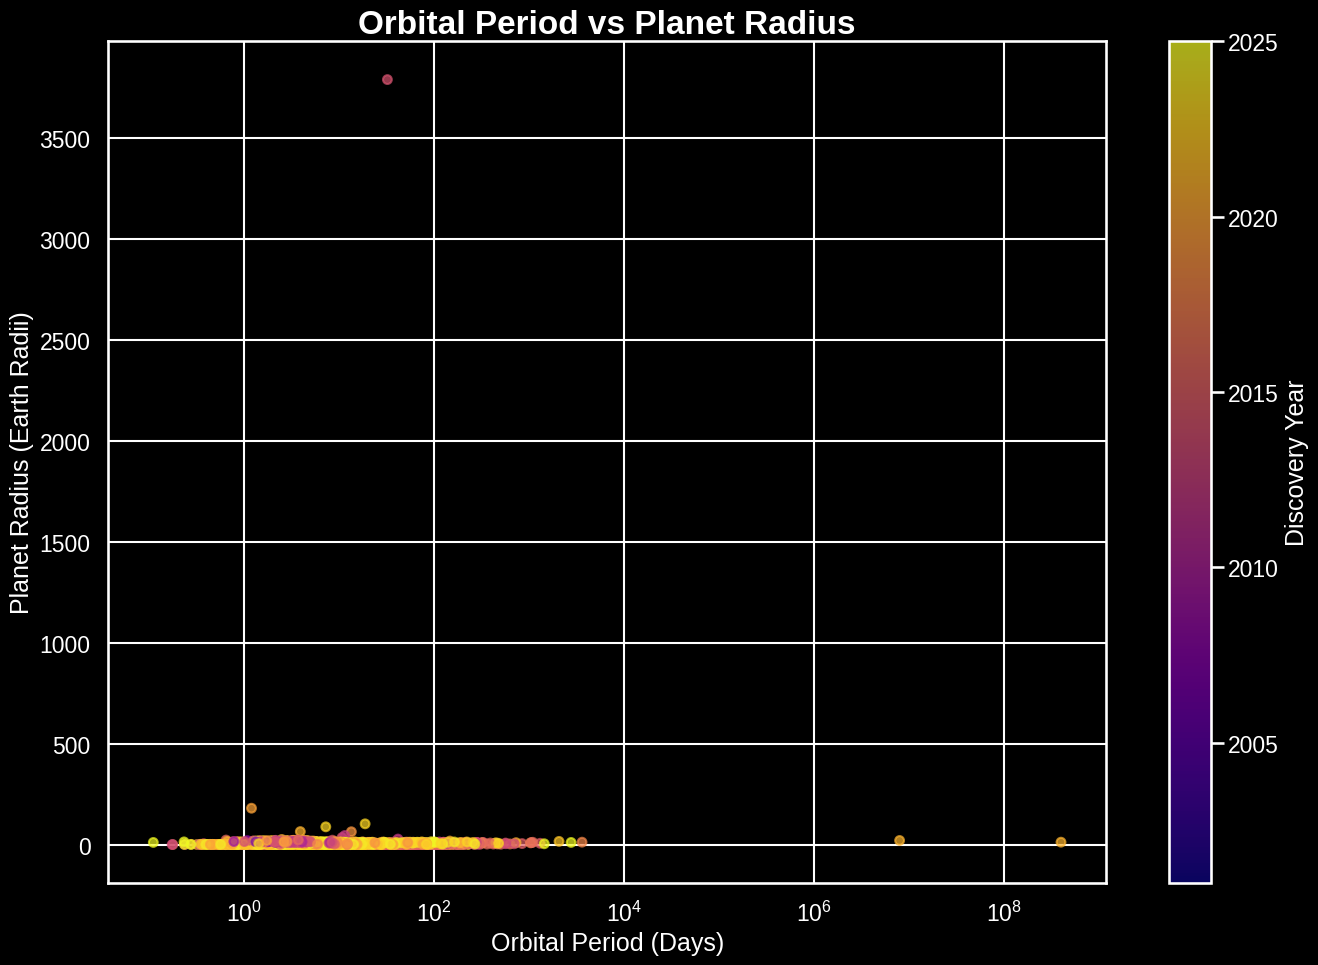

In [42]:
# ============================================================
# VISUALIZATION 3
# ORBITAL PERIOD VS PLANET RADIUS
# ============================================================

plot_df = df.dropna(
    subset=['pl_orbper', 'pl_rade']
)

plt.figure(figsize=(14,10))

scatter = plt.scatter(
    plot_df['pl_orbper'],
    plot_df['pl_rade'],
    c=plot_df['disc_year'],
    cmap='plasma',
    alpha=0.7,
    s=40
)

plt.xscale('log')

cbar = plt.colorbar(scatter)
cbar.set_label('Discovery Year')

plt.title(
    'Orbital Period vs Planet Radius',
    fontsize=24,
    weight='bold'
)

plt.xlabel('Orbital Period (Days)')
plt.ylabel('Planet Radius (Earth Radii)')

plt.tight_layout()
plt.show()

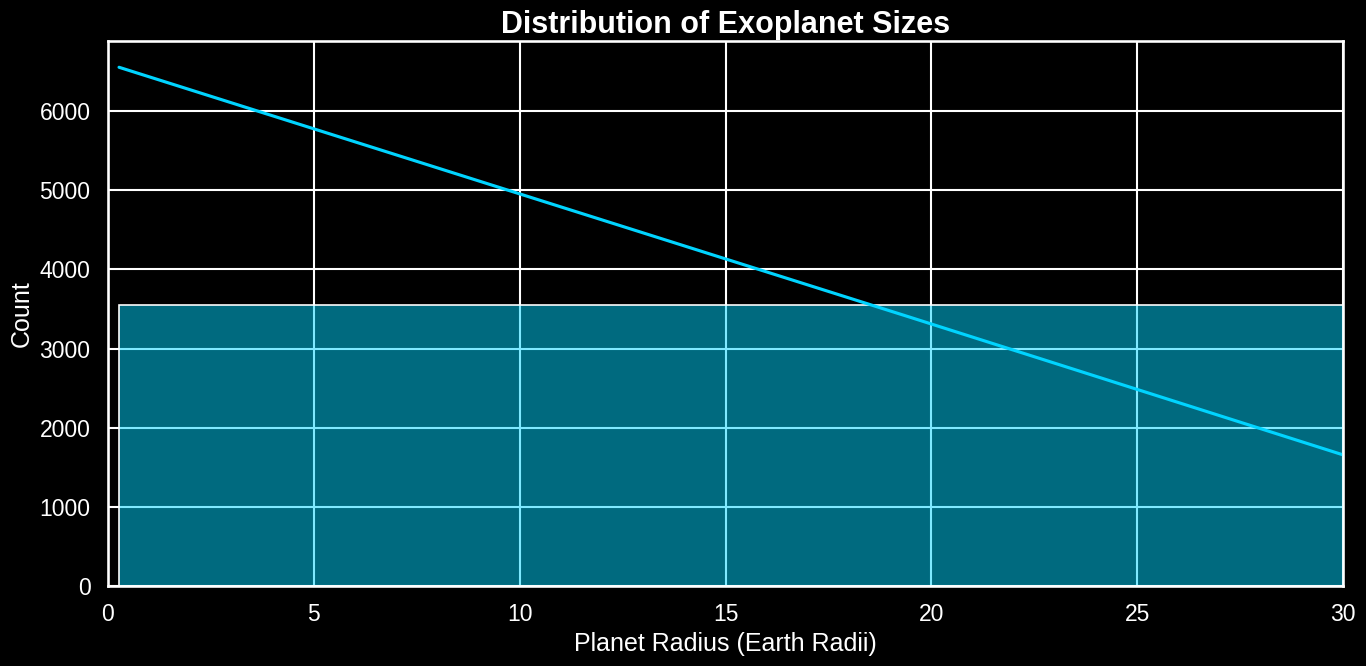

In [46]:
# ============================================================
# VISUALIZATION 4
# PLANET SIZE DISTRIBUTION
# ============================================================

plt.figure(figsize=(14,7))

sns.histplot(
    df['pl_rade'],
    bins=60,
    kde=True,
    color='#00d4ff'
)

plt.title(
    'Distribution of Exoplanet Sizes',
    fontsize=22,
    weight='bold'
)

plt.xlabel('Planet Radius (Earth Radii)')
plt.ylabel('Count')

plt.xlim(0, 30)

plt.tight_layout()
plt.show()

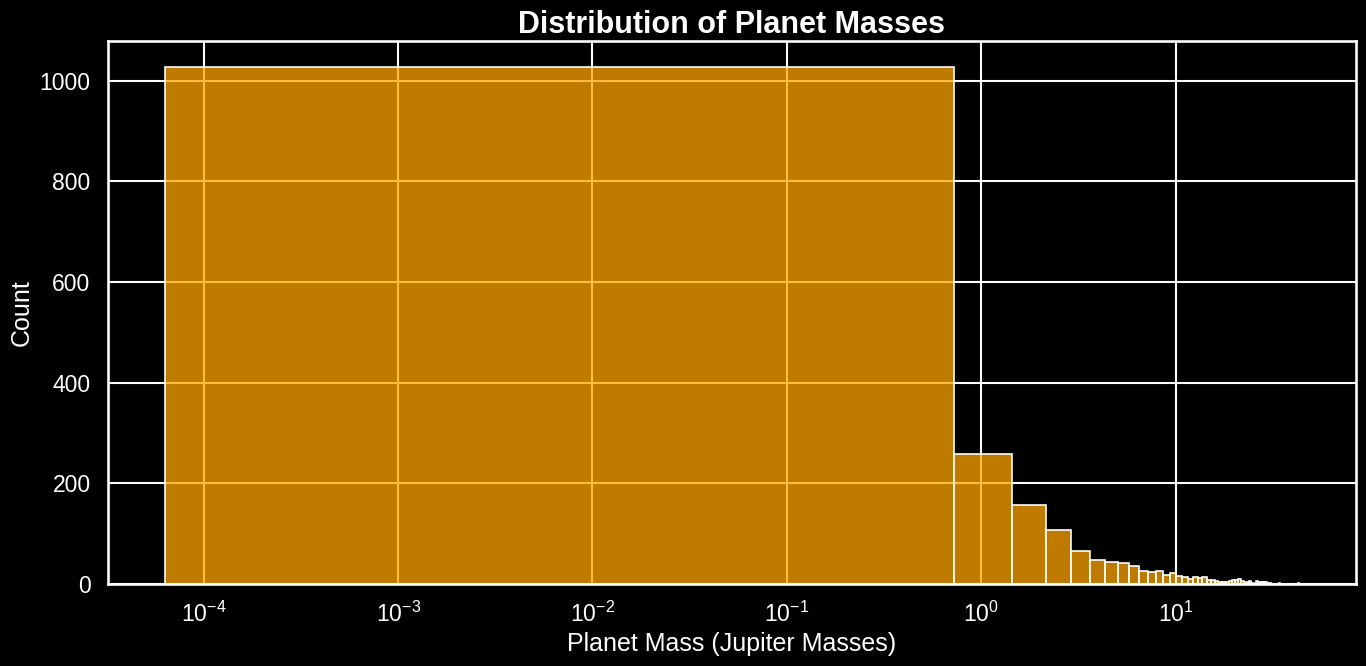

In [47]:
# ============================================================
# VISUALIZATION 5
# PLANET MASS DISTRIBUTION
# ============================================================

mass_df = df.dropna(subset=['pl_bmassj'])

plt.figure(figsize=(14,7))

sns.histplot(
    mass_df['pl_bmassj'],
    bins=60,
    color='orange'
)

plt.xscale('log')

plt.title(
    'Distribution of Planet Masses',
    fontsize=22,
    weight='bold'
)

plt.xlabel('Planet Mass (Jupiter Masses)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

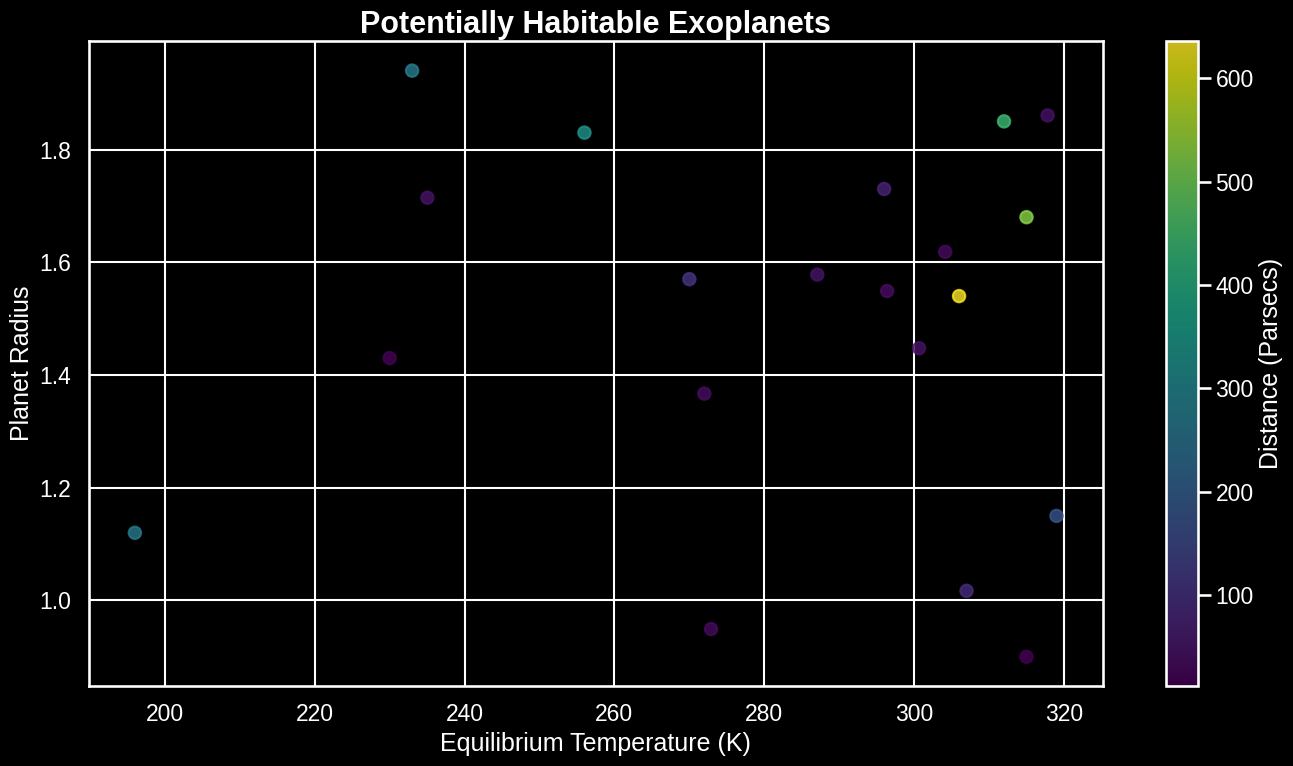

In [48]:
# ============================================================
# VISUALIZATION 6
# HABITABILITY ANALYSIS
# ============================================================

habitable = df[
    (df['pl_eqt'] > 180) &
    (df['pl_eqt'] < 320) &
    (df['pl_rade'] < 2)
]

plt.figure(figsize=(14,8))

scatter = plt.scatter(
    habitable['pl_eqt'],
    habitable['pl_rade'],
    c=habitable['sy_dist'],
    cmap='viridis',
    alpha=0.8,
    s=80
)

cbar = plt.colorbar(scatter)
cbar.set_label('Distance (Parsecs)')

plt.title(
    'Potentially Habitable Exoplanets',
    fontsize=22,
    weight='bold'
)

plt.xlabel('Equilibrium Temperature (K)')
plt.ylabel('Planet Radius')

plt.tight_layout()
plt.show()

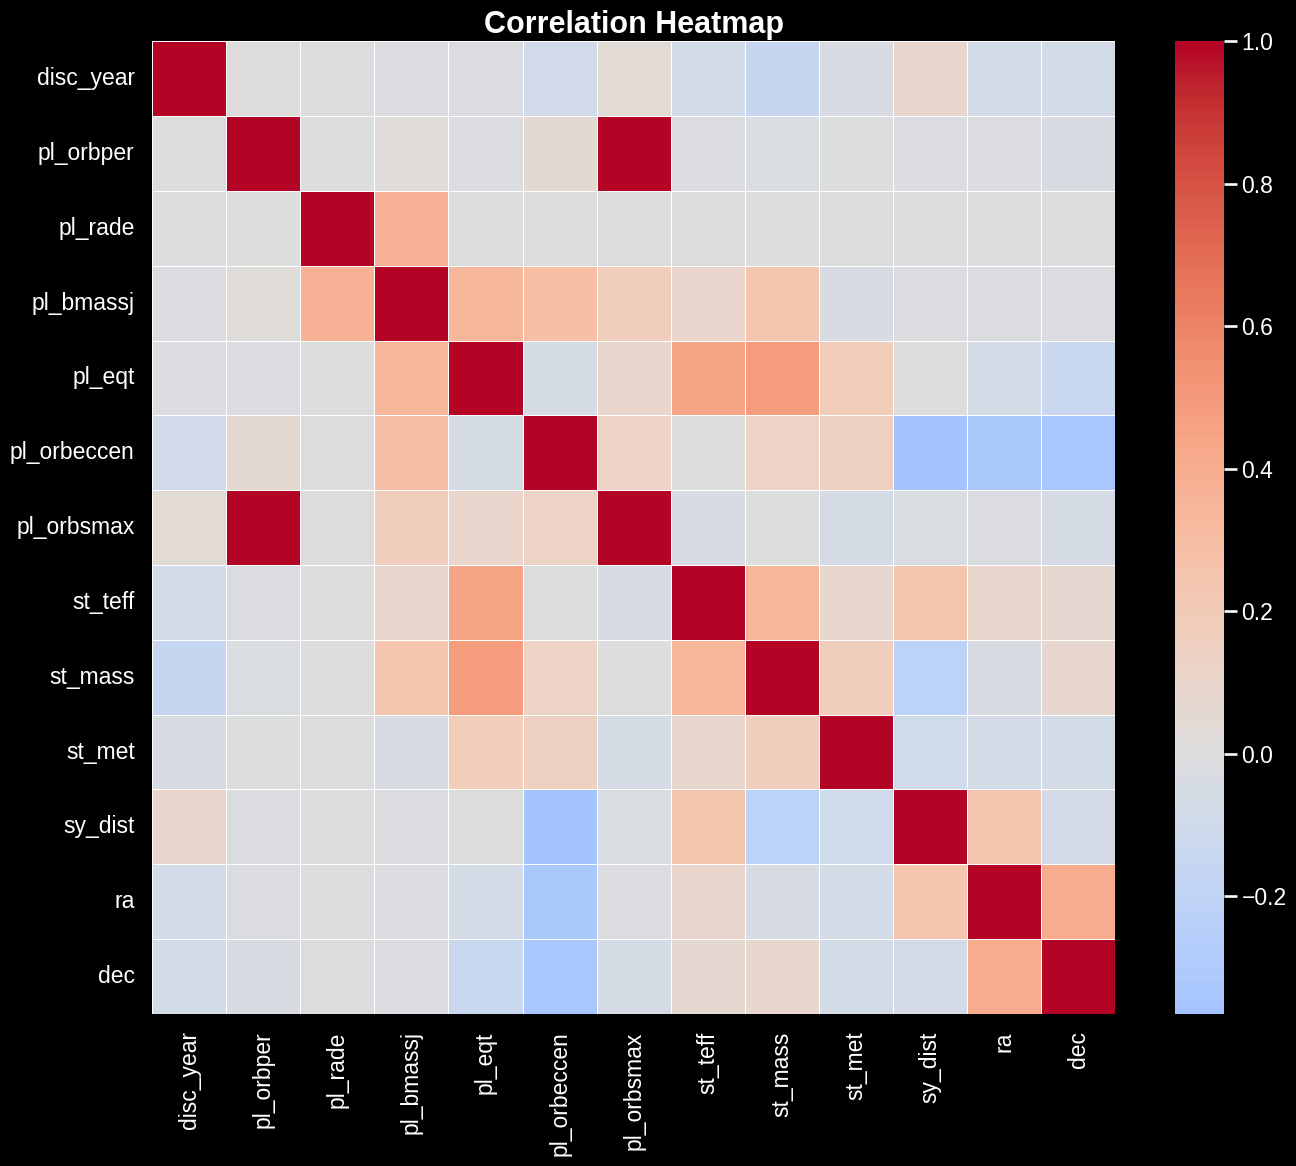

In [49]:
# ============================================================
# VISUALIZATION 7
# CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap',
    fontsize=22,
    weight='bold'
)

plt.tight_layout()
plt.show()

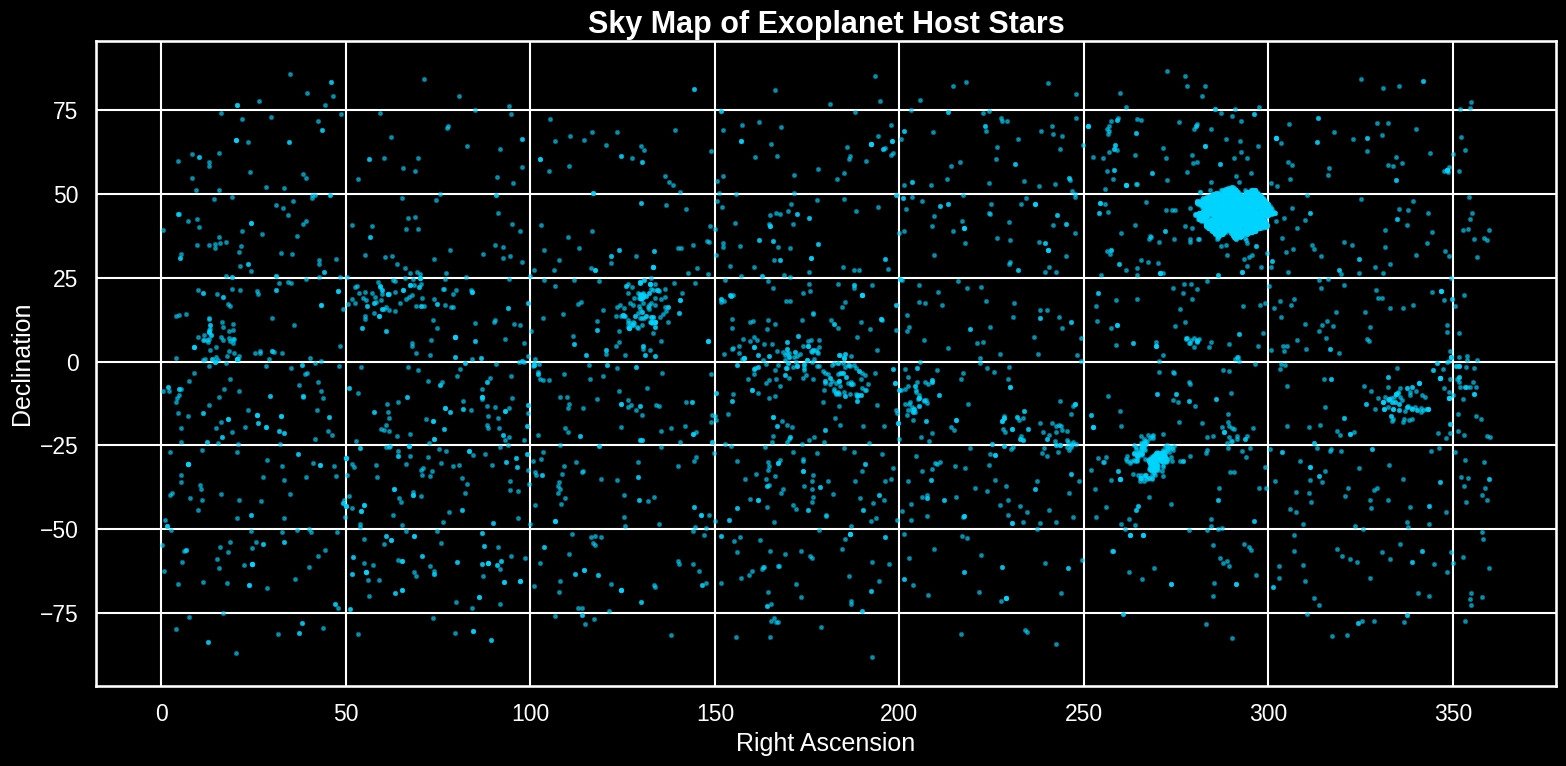

In [52]:
# ============================================================
# VISUALIZATION 8
# SKY MAP OF EXOPLANETS
# ============================================================

sky_df = df.dropna(subset=['ra', 'dec'])

plt.figure(figsize=(16,8))

plt.scatter(
    sky_df['ra'],
    sky_df['dec'],
    s=5,
    alpha=0.5,
    color='#00d4ff'
)

plt.title(
    'Sky Map of Exoplanet Host Stars',
    fontsize=22,
    weight='bold'
)

plt.xlabel('Right Ascension')
plt.ylabel('Declination')

plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# PROJECT SUMMARY
# ============================================================

print("="*60)

print("EXOPLANET PROJECT SUMMARY")

print("="*60)

print(f"Total Unique Exoplanets: {len(df)}")

print(f"Discovery Methods: {df['discoverymethod'].nunique()}")

print(
    f"Years Covered: "
    f"{df['disc_year'].min()} - "
    f"{df['disc_year'].max()}"
)

print("\nTop Discovery Methods:")

print(df['discoverymethod'].value_counts().head())

print("\nPotentially Habitable Planets:")

print(len(habitable))

print("="*60)

EXOPLANET PROJECT SUMMARY
Total Unique Exoplanets: 5972
Discovery Methods: 11
Years Covered: 1992 - 2025

Top Discovery Methods:
discoverymethod
Transit                      4428
Radial Velocity              1130
Microlensing                  249
Imaging                        84
Transit Timing Variations      39
Name: count, dtype: int64

Potentially Habitable Planets:
25
